In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\pruss\Downloads\marketing_campaign (1).csv", sep = "\t")

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
data.isnull().sum()                 # количество пропусков в каждой колонке

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

В колонке доходов видим, что есть 24 пропуска, остальные колонки заполнены полностью

In [5]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
"""sns.boxplot(x=data['Year_Birth'])"""

"sns.boxplot(x=data['Year_Birth'])"

Чтобы сделать опеределение возраста в дальнейшем более наглядным и удобным, заменим год рождения на возраст

 По каждому клиенту у нас есть дата регистрации в Dt_Customer, будет полезно использовать эту информацию как точку расчета его возраста

In [7]:
import datetime

#т.к. дата изначально не в том формате что нужен модулю datetime, переводим её в d-m-Y
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y', errors='coerce')

#удаляем строки, где дата не преобразовалась
data = data.dropna(subset=['Dt_Customer'])
data['Age'] = data['Dt_Customer'].dt.year - data['Year_Birth']

#Year_Birth и Dt_Customer больше не понадобятся, для чистоты таблицы их можно удалить
data.drop('Year_Birth', axis=1, inplace=True)
data.drop('Dt_Customer', axis=1, inplace=True)

#Перемещаем Age в удобное место, после Teenhome
age_col = data.pop('Age')
data.insert(6, 'Age', age_col)

Т.к. нам неинтересна информация о том, в какую из маркетинговых кампаний откликнулся клиент, объединим все эти колонки в одну, которая покажет, откликнулся ли клиент вообще

In [8]:
#список колонок, которые объединим
campaign_cols = ['Response', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

#создаём новую колонку — 1, если хотя бы одна из них равна 1
data['overall_response'] = data[campaign_cols].any(axis=1).astype(int)

#удаляем лишние колонки
data.drop('AcceptedCmp1', axis=1, inplace=True)
data.drop('AcceptedCmp2', axis=1, inplace=True)
data.drop('AcceptedCmp3', axis=1, inplace=True)
data.drop('AcceptedCmp4', axis=1, inplace=True)
data.drop('AcceptedCmp5', axis=1, inplace=True)
data.drop('Response', axis=1, inplace=True)

#ID также ни на что не влияет, от него можно избавиться
data.drop("ID", axis=1, inplace=True)

In [9]:
#объединю колонки "Kidhome" и "Teenhome" в одну "Childhome" для удобства

data['Childhome'] = data['Teenhome'] + data['Kidhome']
data.drop('Kidhome', axis=1, inplace=True)
data.drop('Teenhome', axis=1, inplace=True)

children_col = data.pop('Childhome')
data.insert(4, 'Childhome', children_col)

In [10]:
#Z_CostContact и Z_Revenue технические переменные, в нашей работе бесполезны, удаляем
data.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [11]:
data.head()

,Education,Marital_Status,Income,Age,Childhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,overall_response
0,Graduation,Single,58138.0,55,0,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,Graduation,Single,46344.0,60,2,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,Graduation,Together,71613.0,48,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,Graduation,Together,26646.0,30,1,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,PhD,Married,58293.0,33,1,94,173,43,118,46,27,15,5,5,3,6,5,0,0


Далее я занялся поиском и обработкой выбросов, в данном случае наиболее удобным инструментом оказался "ящик с усами"

In [12]:
"""# Только числовые колонки
numeric_cols = data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data[col])
    plt.title(f'Распределение: {col}')
    plt.show() """

"# Только числовые колонки\nnumeric_cols = data.select_dtypes(include=['number']).columns\n\nfor col in numeric_cols:\n    plt.figure(figsize=(6, 4))\n    sns.boxplot(data[col])\n    plt.title(f'Распределение: {col}')\n    plt.show() "

In [13]:
#самый верхний выброс дохода кажется нереалистичным и его лучше отсеять
data = data[data['Income'] <= 200000]
#возраст регистрации выше 100 также является нереалистичным исключением
data = data[data['Age'] <= 100]

Остальные данные пока что трогать не будем, т.к. они могут быть полезны для сегментации

Далее создадим таблицу сравнения значений для каждой группы потребителей и общего значения в целом. Для числовых значений будем использовать медиану, а для категориальных - моду.

In [14]:
# Создаём колонки-маркеры
data['wine_buyer'] = data['MntWines'] > 0
data['fruits_buyer'] = data['MntFruits'] > 0
data['meat_buyer'] = data['MntMeatProducts'] > 0
data['fish_buyer'] = data['MntFishProducts'] > 0
data['sweet_buyer'] = data['MntSweetProducts'] > 0
data['gold_buyer'] = data['MntGoldProds'] > 0

numeric_features = ['Income', 'Age', 'MntWines', 'MntFruits', 'MntMeatProducts', 
                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

categorical_features = ['Education', 'Marital_Status', 'Childhome']

#функция для создания таблицы
def summary_by_group(data, group_col, numeric_features, categorical_features):
    result = {}
    
    # Для числовых — медиана
    for col in numeric_features:
        result[col] = data.groupby(group_col)[col].median()
    
    # Для категориальных — мода
    for col in categorical_features:
        result[col] = data.groupby(group_col)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    
    return pd.DataFrame(result).T

products = {
    'wine_buyer': 'Покупатели вина',
    'fruits_buyer': 'Покупатели фруктов',
    'meat_buyer': 'Покупатели мяса',
    'fish_buyer': 'Покупатели рыбы',
    'sweet_buyer': 'Покупатели сладостей',
    'gold_buyer': 'Покупатели золота'
}

all_results = {}

for col, label in products.items():
    summary = summary_by_group(data, col, numeric_features, categorical_features)
    all_results[label] = summary[True]

#сборка таблицы
all_clients_median = data[numeric_features].median()
all_clients_mode = data[categorical_features].agg(lambda x: x.mode()[0] if not x.mode().empty else None)
all_clients = pd.concat([all_clients_median, all_clients_mode])

final_table = pd.DataFrame(all_results)

#добавляем колонку по всем клиентам и переставляем её в начало
final_table['Все клиенты'] = all_clients
cols = ['Все клиенты'] + [col for col in final_table.columns if col != 'Все клиенты']
final_table = final_table[cols]

final_table

,Все клиенты,Покупатели вина,Покупатели фруктов,Покупатели мяса,Покупатели рыбы,Покупатели сладостей,Покупатели золота
Income,51371.0,51529.0,54597.0,51373.0,54252.0,54364.0,51373.0
Age,43.0,43.0,43.0,43.0,42.0,42.0,43.0
MntWines,175.5,179.0,204.5,176.0,208.0,202.0,179.0
MntFruits,8.0,8.0,14.0,8.0,12.0,12.0,8.0
MntMeatProducts,68.0,68.0,91.0,68.0,92.0,92.0,69.0
MntFishProducts,12.0,12.0,16.0,12.0,19.0,17.0,12.0
MntSweetProducts,8.0,8.0,12.0,8.0,12.0,14.0,8.0
MntGoldProds,24.5,25.0,29.0,25.0,29.0,29.0,26.0
Education,Graduation,Graduation,Graduation,Graduation,Graduation,Graduation,Graduation
Marital_Status,Married,Married,Married,Married,Married,Married,Married


В целом по таблице выше уже можно сделать вывод о целевом портрете потребителя. Для наглядности проведём визуализацию разных метрик

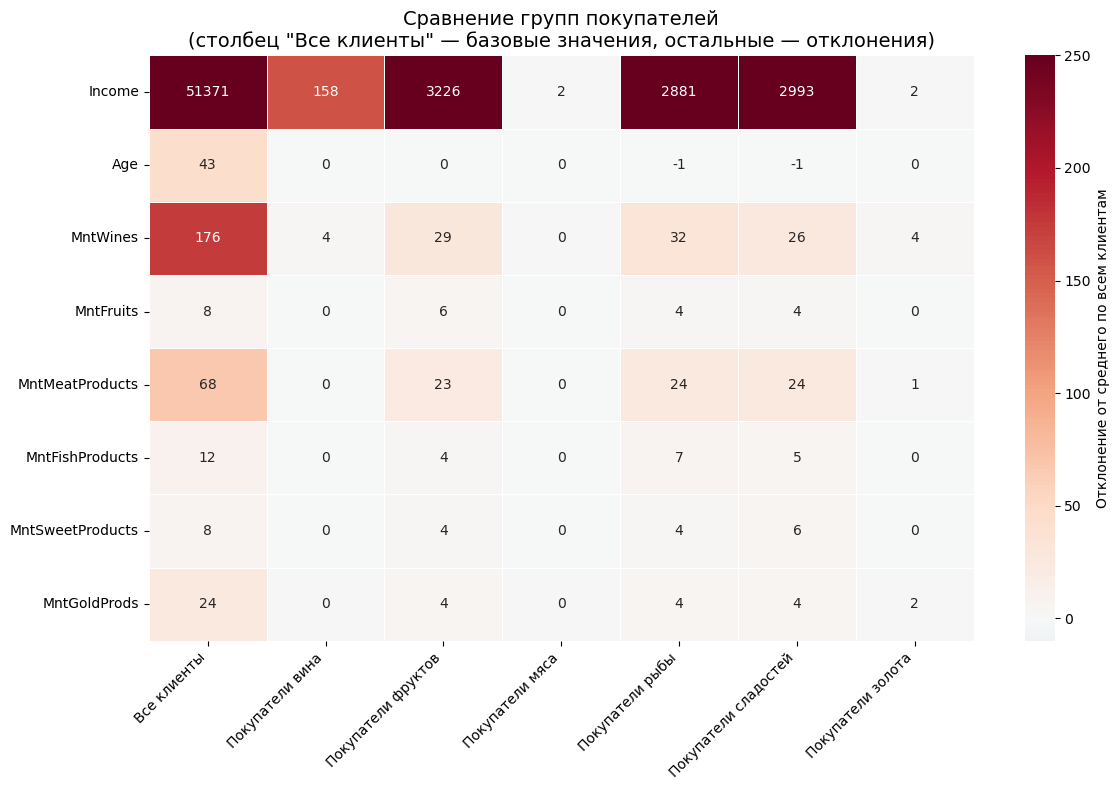

In [27]:
plot_data = final_table.loc[numeric_features].copy().astype(float)

#Сохраняем базовый столбец
baseline = plot_data['Все клиенты']

# 3. Вычитаем базовый столбец из ВСЕХ (включая его самого)
plot_data_diff = plot_data.subtract(baseline, axis=0)

# 4. Теперь в столбце «Все клиенты» — нули.
#    Заменяем их на исходные значения (медианы)
plot_data_diff['Все клиенты'] = baseline.values

# 5. Строим тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(plot_data_diff, 
            annot=True, 
            fmt='.0f', 
            cmap='RdBu_r', 
            center=0,
            vmin=-10,
            vmax=250,
            cbar_kws={'label': 'Отклонение от среднего по всем клиентам'},
            linewidths=0.5,
            linecolor='white')

plt.title('Сравнение групп покупателей\n'
          '(столбец "Все клиенты" — базовые значения, остальные — отклонения)', 
          fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

То что практически в каждой ячейке показатели выше среднего по всем клиентам это нормально, т.к. группы часто пересекаются и происходит подсчет дважды, однако это не меняет картины отклонения в целом

<Axes: xlabel='Группа', ylabel='Income'>

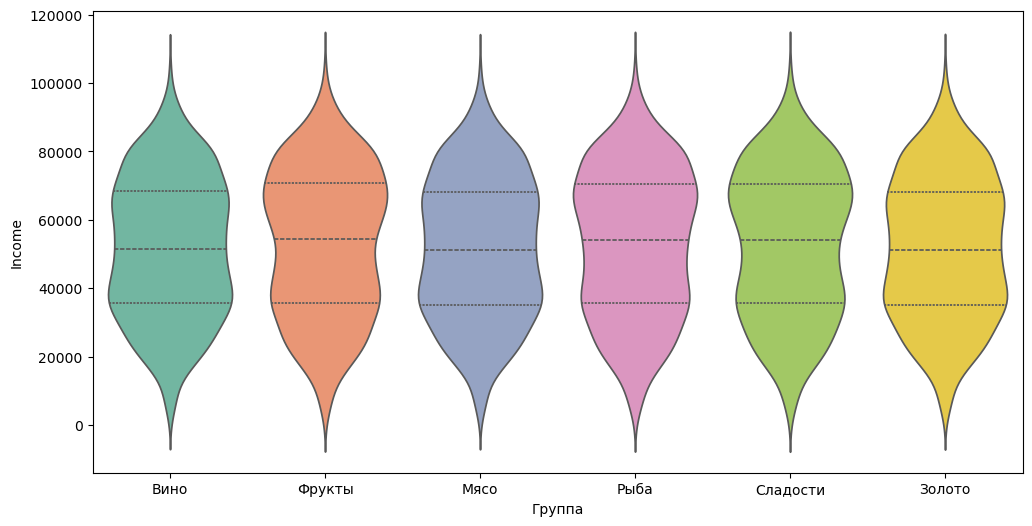

In [26]:
# Создаём список групп
buyer_cols = ['wine_buyer', 'fruits_buyer', 'meat_buyer', 'fish_buyer', 'sweet_buyer', 'gold_buyer']
labels = ['Вино', 'Фрукты', 'Мясо', 'Рыба', 'Сладости', 'Золото']

plt.figure(figsize=(12, 6))

#Собираем данные в один DataFrame
violin_data = pd.DataFrame()

#ограничим значения дохода, для более красивой визуализации

data = data[data['Income'] <= 110000]

for col, label in zip(buyer_cols, labels):
    temp = data[data[col] == True][['Income']].copy()
    temp['Группа'] = label
    violin_data = pd.concat([violin_data, temp])

#Строим violin plot
sns.violinplot(data=violin_data, 
               x='Группа', 
               y='Income', 
               hue='Группа', 
               inner='quartile', 
               palette='Set2', 
               legend=False)

По пунктирным линиям видно, что у покупателей фруктов распределение немного смещено вверх, однако в целом распределения очень похожи друг на друга, значит доход не является сильным разделителем по группам

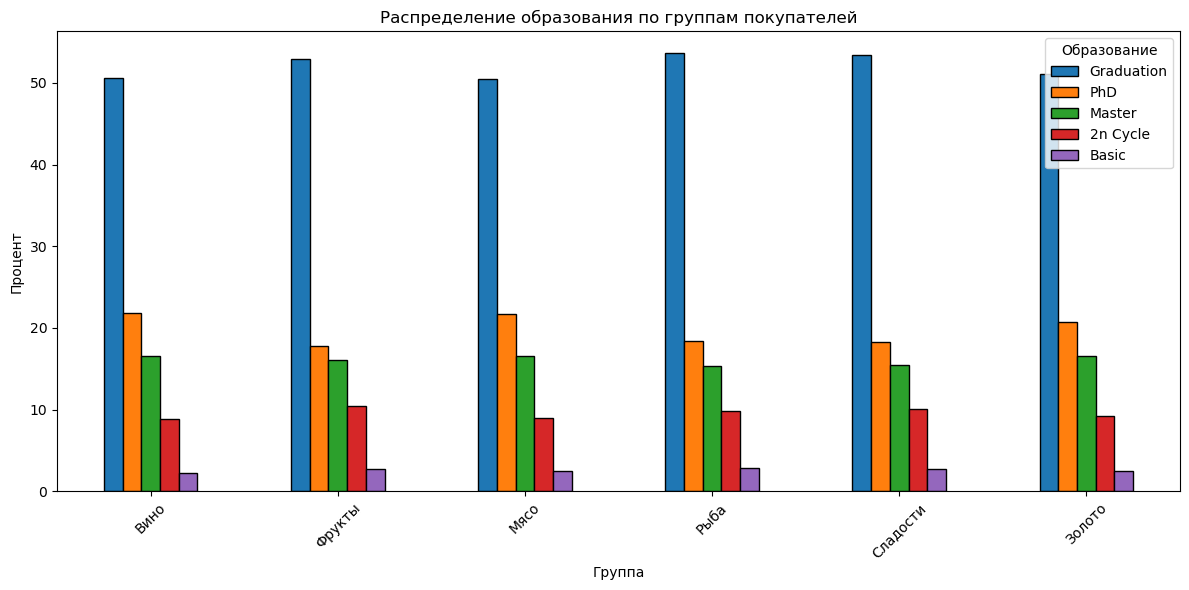

In [18]:
# Создаём сводную таблицу: образование по каждой группе (в процентах)
products = {
    'wine_buyer': 'Вино',
    'fruits_buyer': 'Фрукты',
    'meat_buyer': 'Мясо',
    'fish_buyer': 'Рыба',
    'sweet_buyer': 'Сладости',
    'gold_buyer': 'Золото'
}

edu_summary = {}

for col, label in products.items():
    # Процент Graduation среди покупателей
    edu_summary[label] = data[data[col] == True]['Education'].value_counts(normalize=True) * 100

# Объединяем в один DataFrame
edu_df = pd.DataFrame(edu_summary).fillna(0)

# Визуализация
edu_df.T.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Распределение образования по группам покупателей')
plt.ylabel('Процент')
plt.xlabel('Группа')
plt.xticks(rotation=45)
plt.legend(title='Образование')
plt.tight_layout()
plt.show()